In [1]:
using Distributed
using Pkg
Pkg.activate("/home/chrisstrong/MRI_Driving/inverse-feedback-games/")

nprocs = Distributed.nprocs()

num_desired_procs = 1
if num_desired_procs > Distributed.nprocs() 
    println("adding ", num_desired_procs - Distributed.nprocs(), " processes")
    Distributed.addprocs(num_desired_procs - Distributed.nprocs())
end

@everywhere begin 
    using Pkg
    using iLQGames
    import iLQGames: dx
    using Plots
    using ForwardDiff
    using iLQGames:
        SystemTrajectory
    using iLQGames:
        LinearSystem
    using Infiltrator
    using Optim
    using LinearAlgebra
    using Dates
    using Statistics

    include("../src/diff_solver.jl")
    include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

    # added imports by Chris 
    ENV["PYTHON"] = "/home/chrisstrong/miniconda3/envs/brain_env"
    Pkg.build("PyCall")
    using PyCall
    import Base.length
    using BenchmarkTools
    using LazySets
    using LinearAlgebra
    using NPZ
    using Plots
    using Random

    include("../src/geometric_utils.jl")
end

  Activating project at `~/MRI_Driving/inverse-feedback-games`
[ Info: Precompiling iLQGames [ae812560-bd7e-11e9-3bd3-b502f7cff3d3]
[ Info: Precompiling Optim [429524aa-4258-5aef-a3af-852621145aeb]
[ Info: Precompiling LazySets [b4f0291d-fe17-52bc-9479-3d1a343d9043]
    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/b19db3927f0db4151cb86d073689f2428e524576/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`
Precompiling project...
  ✓ Distances → DistancesChainRulesCoreExt
  ✓ Dbus_jll
  ? Xorg_libXrandr_jll
  ? Xorg_libXinerama_jll
  ✓ Wayland_jll
  ? Xorg_libxkbfile_jll
  ? Xorg_xcb_util_jll
  ? Libglvnd_jll
  ? Xorg_libXfixes_jll
  ? ImageCore
  ? Xorg_xcb_util_image_jll
  ? Xorg_xcb_util_renderutil_jll
  ? Xorg_xcb_util_keysyms_jll
  ? Xorg_xcb_util_wm_jll
  ✓ Xorg_libXi_jll
  ✓ Xorg_xkbcomp_jll
  ✓ Xorg_libXcursor_jll
  ✓ Xorg_xkeyboard_config_jll
  ? NLsol

In [ ]:
using SharedArrays

n_dim = 100
n_internal_loops = 1000
n_examples = 400
function parallel_distributed_test()
    a = SharedArray{Float64}(n_examples, n_dim, n_dim) 
    @distributed for i = 1:n_examples
        for j = 1:n_internal_loops
            z = randn(n_dim, n_dim)
        end
        b = randn(n_dim, n_dim)
        c = randn(n_dim, n_dim)
        a[i, :, :] = b * c
    end
    return a
end

function parallel_threads_test()
    a = zeros(n_examples, n_dim, n_dim)
    Threads.@threads for i = 1:n_examples
        for j = 1:n_internal_loops
            z = randn(n_dim, n_dim)
        end
        b = randn(n_dim, n_dim)
        c = randn(n_dim, n_dim)
        a[i, :, :] = b * c
    end
end 

function linear_test() 
    a = zeros(n_examples, n_dim, n_dim)
    for i = 1:n_examples
        for j = 1:n_internal_loops
            z = randn(n_dim, n_dim)
        end
        b = randn(n_dim, n_dim)
        c = randn(n_dim, n_dim)
        a[i, :, :] = b * c
    end
end


@benchmark parallel_distributed_test() 

BenchmarkTools.Trial: 9 samples with 1 evaluation.
 Range (min … max):  566.820 ms … 575.690 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     567.682 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   570.133 ms ±   3.402 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

       █                                                         
  ▆▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▁▁▁▁▁▁▆▁▁▁▁▁▁▁▁▁▆ ▁
  567 ms           Histogram: frequency by time          576 ms <

 Memory estimate: 2.53 MiB, allocs estimate: 53345.

In [ ]:
@benchmark parallel_threads_test() 

BenchmarkTools.Trial: 7 samples with 1 evaluation.
 Range (min … max):  775.491 ms … 817.078 ms  ┊ GC (min … max): 23.41% … 24.78%
 Time  (median):     798.466 ms               ┊ GC (median):    25.28%
 Time  (mean ± σ):   796.236 ms ±  15.372 ms  ┊ GC (mean ± σ):  24.79% ±  0.98%

  █    █               █           █        █     █           █  
  █▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁█▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁█ ▁
  775 ms           Histogram: frequency by time          817 ms <

 Memory estimate: 29.96 GiB, allocs estimate: 1595583.

In [ ]:
@benchmark linear_test()

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 8.080 s (14.39% GC) to evaluate,
 with a memory estimate of 29.96 GiB, over 1594803 allocations.

In [ ]:
# using BenchmarkTools

# n_dim = 100
# n_examples = 10000
# function parallel_test()
#     a = zeros(n_examples, n_dim, n_dim)
#     Threads.@threads for i = 1:n_examples
#         b = randn(n_dim, n_dim)
#         c = randn(n_dim, n_dim)
#         a[i, :, :] = b * c
#     end
# end 

### Data processing utils

In [ ]:
@everywhere begin 
    function vehicle_index_to_col(index)
        return 6 + 5*(index - 1)
    end

    function pedestrian_index_to_col(index, k_closest_vehicles)
        return 6 + 5*k_closest_vehicles + 5*(index - 1)
    end

    function centerline_col(k_closest_vehicles, k_closest_pedestrians)
        return 6 + 5*k_closest_vehicles + 5*k_closest_pedestrians
    end

    function relu(x)
        return max.(0, x)
    end

    k_closest_vehicles = 15
    k_closest_pedestrians = 0
end

### Loading trajectory data

In [ ]:
py"""
import pickle
 
def load_pickle(fpath):
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    return data
"""

load_pickle = py"load_pickle"

train_demonstrations_turns = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")
train_point_sequences = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_point_sequences.pkl")

validation_demonstrations_turns = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/validation_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")
validation_point_sequences = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/validation_point_sequences.pkl")


# Load centerlines 
centerline_filename = "/data/fmri/full_dataset/map_centerlines.npz"
centerlines = npzread(centerline_filename)["lines"]
centerlines = [LineSegment(centerlines[i, 1, :], centerlines[i, 2, :]) for i in 1:size(centerlines, 1)]


49-element Vector{LineSegment{Int64, Vector{Int64}}}:
 LineSegment{Int64, Vector{Int64}}([644, 0], [81685, 0])
 LineSegment{Int64, Vector{Int64}}([0, 814], [0, 97766])
 LineSegment{Int64, Vector{Int64}}([6577, 459], [6572, 8472])
 LineSegment{Int64, Vector{Int64}}([11507, 459], [11507, 8472])
 LineSegment{Int64, Vector{Int64}}([16427, 459], [16427, 8472])
 LineSegment{Int64, Vector{Int64}}([22188, 459], [22188, 25010])
 LineSegment{Int64, Vector{Int64}}([42719, 459], [42719, 53736])
 LineSegment{Int64, Vector{Int64}}([49291, 459], [49291, 29926])
 LineSegment{Int64, Vector{Int64}}([55863, 459], [55863, 12666])
 LineSegment{Int64, Vector{Int64}}([66542, 459], [66542, 12666])
 LineSegment{Int64, Vector{Int64}}([74758, 459], [74758, 29926])
 LineSegment{Int64, Vector{Int64}}([82151, 459], [82151, 97717])
 LineSegment{Int64, Vector{Int64}}([644, 9037], [21525, 9037])
 ⋮
 LineSegment{Int64, Vector{Int64}}([48929, 74758], [62805, 74758])
 LineSegment{Int64, Vector{Int64}}([69828, 69459], [69

Rescaling data

In [ ]:
# Set some parameters
road_width_cm = 1200
@everywhere scaling_factor = 2000

# Rescale the map
scaled_centerlines = [LineSegment(centerline.p / scaling_factor, centerline.q / scaling_factor) for centerline in centerlines]

# Rescale the train demonstration states 
train_demonstrations_turns_states = [train_demonstration[1] for train_demonstration in train_demonstrations_turns]
validation_demonstrations_turns_states = [validation_demonstration[1] for validation_demonstration in validation_demonstrations_turns]

indices_to_scale = [1, 2, 4, 5] # x, y, v, a
for j = 1:k_closest_vehicles
    cur_col = vehicle_index_to_col(j)
    append!(indices_to_scale, [cur_col, cur_col + 1, cur_col + 3, cur_col + 4])
end 
centerline_index = centerline_col(k_closest_vehicles, k_closest_pedestrians)
append!(indices_to_scale, [centerline_index, centerline_index + 1, centerline_index + 2, centerline_index + 3])

scaled_train_demonstration_states = deepcopy(train_demonstrations_turns_states)
scaled_validation_demonstration_states = deepcopy(validation_demonstrations_turns_states)
for i = 1:length(train_demonstrations_turns_states)
    scaled_train_demonstration_states[i][:, indices_to_scale] /= scaling_factor
end

for i = 1:length(validation_demonstrations_turns_states)
    scaled_validation_demonstration_states[i][:, indices_to_scale] /= scaling_factor
end 

# Scale the train_point_sequences 
scaled_train_point_sequences = train_point_sequences / scaling_factor
scaled_validation_point_sequences = validation_point_sequences / scaling_factor

# Scale the road width
scaled_road_width = road_width_cm / scaling_factor


0.6

Utilities for generating the plan 

In [ ]:
@everywhere begin 

    function road_shift_from_points(point1, point2, road_width)
        # Since we're using a left handed coordinate
        # if we're going in the positive x direction (left), the road shift is up in y 
        # if we're going in the negative x direction (right), the road shift is down in y 
        # if we're going in the positive y direction (up), the road shift is negative in x (right)
        # if we're going in the negative y direction (down), the road shift is positive in y (left)
        start_x, start_y, second_x, second_y = point1[1], point1[2], point2[1], point2[2]
        # assert x is constant or y is constant 
        @assert (start_x ≈ second_x || start_y ≈ second_y)

        if start_x < second_x
            road_shift = [0, road_width / 4]
        elseif start_x > second_x
            road_shift = [0, -road_width / 4]
        elseif start_y < second_y
            road_shift = [-road_width / 4, 0]
        elseif start_y > second_y
            road_shift = [road_width / 4, 0]
        end
        return road_shift
    end

    function shorten_segment(segment::LineSegment, dist_to_cut, direction="both")
        p, q = segment.p, segment.q
        v = q - p
        v = v / norm(v)
        if direction == "both"
            return LineSegment(p + v * dist_to_cut, q - v * dist_to_cut)
        elseif direction == "start"
            return LineSegment(p + v * dist_to_cut, q)
        elseif direction == "end"
            return LineSegment(p, q - v * dist_to_cut)
        else 
            error("Invalid direction")
        end
    end 

    function is_right_turn(direction_1, direction_2)
        # in left-handed coordinates, check to see if the turn is right. 
        # direction_1 should be the direction you start heading, and direction 2 should be the direction you end up heading 
        # if the cross product of the two vectors is positive, then it's a right turn
        return cross([direction_1; 0], [direction_2; 0])[3] > 0
    end

    function trajectory_plan_from_key_points(key_points, road_width)
        # go along alternating between straights and arcs, is that always right? 
        # we'll note that we're in a left handed coordinate system, so left is more positive xs and right is 
        trajectory_segments = []
        
        # From the first two points get a line 
        point1, point2 = key_points[1], key_points[2]
        road_shift = road_shift_from_points(point1, point2, road_width)
        line_segment = LineSegment(point1 + road_shift, point2 + road_shift)
        # shorten the end of the line segment by 0.5*road_width 
        line_segment = shorten_segment(line_segment, 0.5*road_width, "end")
        push!(trajectory_segments, line_segment)

        # now for each trio we'll add a curve then a straight 
        for i = 1:(length(key_points) - 2)
            point1, point2, point3 = key_points[i], key_points[i+1], key_points[i+2]

            # get the vector from point1 to point2
            direction_1 = (point2 - point1) / norm(point1 - point2)
            # get the vector from point2 to point3
            direction_2 = (point3 - point2) / norm(point3 - point2)

            # add on the segment from point 2 to point 3 
            road_shift = road_shift_from_points(point2, point3, road_width)
            line_segment = LineSegment(point2 + road_shift, point3 + road_shift)
            # shorten line segment on both sides by 0.5*road_width unless we're on the last index
            # in which case we just shorten the start and not the end  
            if i == length(key_points) - 2
                line_segment = shorten_segment(line_segment, 0.5*road_width, "start")
            else 
                line_segment = shorten_segment(line_segment, 0.5*road_width, "both")
            end

            right_turn = is_right_turn(-direction_1, direction_2)
            center_shift_amount = road_width / 2 # shift from center or road point to the center of circle    #right_turn ? road_width / 4 : road_width / 2 # 
            circle_center = point2 - center_shift_amount * direction_1 + center_shift_amount * direction_2 # point2 - center_shift_amount * direction_1 + center_shift_amount * direction_2
            
            # now see the angle from the end of the previous line segment to this circle 
            previous_line_segment = trajectory_segments[end]

            previous_end = previous_line_segment.q
            start_angle = atan(previous_end[2] - circle_center[2], previous_end[1] - circle_center[1])
            
            # now see the angle from the start of the next line segment to this circle 
            next_line_segment = line_segment
            next_start = next_line_segment.p
            end_angle = atan(next_start[2] - circle_center[2], next_start[1] - circle_center[1])

            clockwise = right_turn 
            circle_radius = right_turn ? road_width * 3/4 : road_width / 4# in left-handed coordinate system right turns have larger radius 
            arc = Arc(circle_center, circle_radius, start_angle, end_angle, clockwise)
            
            push!(trajectory_segments, arc)
            push!(trajectory_segments, line_segment)
        end
        
        return ListTrajectoryPlan(trajectory_segments)
    end 
end 

[[4.1075, 15.11825], [4.1075, 12.7335], [8.215, 12.7335], [8.215, 23.46565]]


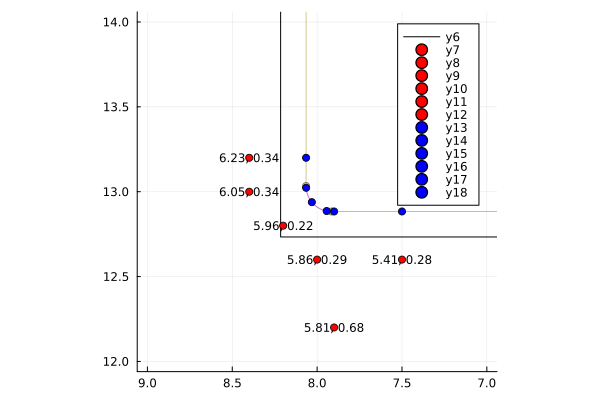

In [ ]:
plot()
i = 5
println(scaled_train_point_sequences[i])
trajectory_plan = trajectory_plan_from_key_points(scaled_train_point_sequences[i], scaled_road_width)
#dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
visualize(trajectory_plan)
plot!([point[1] for point in scaled_train_point_sequences[i]], [point[2] for point in scaled_train_point_sequences[i]], color="black")
xflip!(true)
plot!(xlims = [7, 9])
plot!(ylims = [12, 14])
plot!(aspect_ratio=:equal)

# generate random points, project onto trajectory 
num_points = 5
points = [[7.5, 12.6], [7.9, 12.2], [8, 12.6], [8.2, 12.8], [8.4, 13.2], [8.4, 13.0]]#[[4, 15], [4, 13], [4, 10], [5, 10], [7, 10], [8, 10], [8, 12], [8, 14], [8, 20.]]# [[3 * rand(), 5 * rand()] - [3, 1] for _ in 1:num_points]

# for each point get its frenet coordinates and the point 
frenet_results = [project_frenet_coordinates(point, trajectory_plan) for point in points]
distances_along_curve, distances_from_curve, projected_points = zip(frenet_results...)

for (point, distance_along_curve, distance_from_curve) in zip(points, distances_along_curve, distances_from_curve)
    scatter!([point[1]], [point[2]], color="red")
    # label each with distance along curve and distance from curve after rounding to 2 digits
    label = "$(round(distance_along_curve, digits=2)), $(round(distance_from_curve, digits=2))"
    annotate!([point[1]], [point[2]], text(label, 8, :black))
end

for point in projected_points
    scatter!([point[1]], [point[2]], color="blue")
end
plot!()


4.71238898038469
0.0
start: 4.71238898038469
end: 6.283185307179586


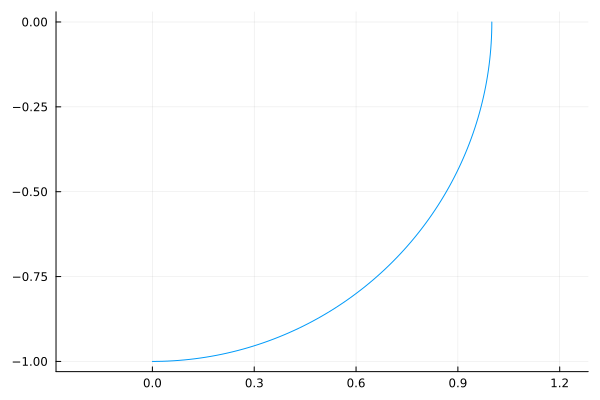

In [ ]:
function visualize(arc::Arc; kwargs...)
    start_angle, end_angle = arc.start_angle, arc.end_angle
    if arc.clockwise
        # have the values decreasing, so get it so that end_angle < start_angle. 
        if end_angle > start_angle
            end_angle = end_angle - 2*pi
        end
    else 
        if end_angle < start_angle 
            end_angle = end_angle + 2*pi
        end
    end
    println(arc.start_angle)
    println(arc.end_angle)
    println("start: ", start_angle)
    println("end: ", end_angle)
    angles = LinRange(start_angle, end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    return plot!([p[1] for p in points], [p[2] for p in points]; label="", kwargs...)
end

plot()
x = Arc([0.0, 0.0], 1.0, -pi/2, 0, false)
visualize(x)
plot!(aspect_ratio=:equal)


### Setting up our actual solver

Setup for all demos

In [ ]:
@everywhere begin 
    nx, nu, ΔT, game_horizon = 5, 2, 1/15, 30
    ΔT_data = 1/15
    angular_control_scaling = 1
    velocity_control_scaling = 1

    # setup the dynamics
    struct SingleUnicycleTimeAugmented <: ControlSystem{ΔT,nx,nu} end
    # state: (px, py, phi, v)
    dx(cs::SingleUnicycleTimeAugmented, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1] / angular_control_scaling, u[2] / velocity_control_scaling, 0.0 ) # last element of state is the initial time 
    dynamics = SingleUnicycleTimeAugmented()

    # Setting parameters
    ego_v_desired = 600 / scaling_factor 

    ego_weight_distance_along_curve = 0.01
    ego_weight_distance_from_curve = 10.0
    ego_weight_velocity = 5.0
    ego_weight_control_1 = 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2
    ego_weight_control_2 = 1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2
    
    ego_comfortable_distance = 900 / scaling_factor 
    scaling_distance_from_curve = 3.0

    n_other_vehicles_for_cost = 3
    ego_weight_distance = 2.0

end 


Set parameters

In [ ]:


# ego_v_desired = 800 / scaling_factor 
# ego_comfortable_distance = 1000 / scaling_factor 
# scaling_distance_from_curve = 3

# ego_weight_distance_along_curve = 0.0
# ego_weight_distance_from_curve = 90.0
# ego_weight_velocity = 30.0
# ego_weight_control_1 = 14.0 / (scaling_factor / 1000)^2 / (control_scaling)^2
# ego_weight_control_2 = 14.0 / (scaling_factor / 1000)^2 / (control_scaling)^2

# n_other_vehicles_for_cost = 3
# ego_weight_distance = 40.0

Demonstration specific setup

In [ ]:
@everywhere function cost_function_feature_gen_for_demonstration(scaled_demonstration_states, scaled_train_point_sequence, scaled_road_width)
    # Generate your trajectory then setup projection onto it
    trajectory_plan = trajectory_plan_from_key_points(scaled_train_point_sequence, scaled_road_width)
    function wrapper_fcn(point)
        dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
        return [dist_along_curve, dist_from_curve]
    end 

    function ego_vehicle_cost(g, x, u, t)
        # cost for ego vehicle
        ego_x, ego_y, ego_phi, ego_v, start_time = x[1:5]
        ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])
        
        # cost including distance along curve, distance from curve, speed, and control cost 
        cur_cost = -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control_1 * u[1]^2 +  ego_weight_control_2 * u[2]^2

        # add on a cost based on the positions of the other vehicles
        # get index of this time step 
        # round t / delta T to an int 
        t_index = floor(Int, (start_time + t) / ΔT_data) + 1

        for i = 1:n_other_vehicles_for_cost
            vehicle_col = vehicle_index_to_col(i)
            vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a = scaled_demonstration_states[t_index, vehicle_col:vehicle_col + 4]
            vehicle_distance_along_curve, vehicle_distance_from_curve = wrapper_fcn([vehicle_x, vehicle_y])
            
            cur_distance = sqrt(scaling_distance_from_curve*(vehicle_distance_from_curve - ego_distance_from_curve)^2 + (vehicle_distance_along_curve - ego_distance_along_curve)^2)
            if cur_distance < ego_comfortable_distance
                cur_cost += ego_weight_distance * (ego_comfortable_distance - cur_distance)^2
            end
        end
        return cur_cost
    end

    function features_from_moment_in_horizon(g, x, u, t, i, x0)
        features = []
        feature_names = []

        # cost for ego vehicle
        ego_x, ego_y, ego_phi, ego_v, start_time = x[1:5]
        ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

        t_str = "t="*string(round(t, digits=3))*"_"


        ego_x_0, ego_y_0, ego_phi_0, ego_v_0 = x0[1:4]
        ego_distance_along_curve_0, ego_distance_from_curve_0 = wrapper_fcn([ego_x_0, ego_y_0])

        # absolute coordinates 
        append!(features, [ego_x, ego_y, ego_phi, ego_v]) # 1-4
        append!(feature_names, ["ego_x_global", "ego_y_global", "ego_phi_global", "ego_v_global"])

        # relative coordinates 
        if t > 0.0 # otherwise these are just 0
            append!(features, [ego_x - ego_x_0, ego_y - ego_y_0, ego_phi - ego_phi_0, ego_v - ego_v_0]) # 5-8
            append!(feature_names, ["ego_x_relative", "ego_y_relative", "ego_phi_relative", "ego_v_relative"])
        end 

        # cost including distance along curve, distance from curve, speed, and control cost 
        cur_cost = -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control_1 * u[1]^2 +  ego_weight_control_2 * u[2]^2

        if i == game_horizon
            append!(features, [ego_distance_along_curve, ego_distance_from_curve, ego_distance_from_curve^2, (ego_v - ego_v_desired)^2]) # 9-14
            append!(feature_names, ["ego_distance_along_curve", "ego_distance_from_curve", "ego_distance_from_curve_squared", "(ego_v-ego_v_desired)_squared"])
        else
            append!(features, [ego_distance_along_curve, ego_distance_from_curve, ego_distance_from_curve^2, (ego_v - ego_v_desired)^2, u[1]^2, u[2]^2]) # 9-14
            append!(feature_names, ["ego_distance_along_curve", "ego_distance_from_curve", "ego_distance_from_curve_squared", "(ego_v-ego_v_desired)_squared", "u_1_squared", "u_2_squared"])    
        end



        # add on a cost based on the positions of the other vehicles
        # get index of this time step 
        # round t / delta T to an int 
        t_index = floor(Int, (start_time + t) / ΔT_data) + 1
        t_index_start_time = floor(Int, start_time / ΔT_data) + 1

        for i = 1:n_other_vehicles_for_cost
            vehicle_col = vehicle_index_to_col(i)
            vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a = scaled_demonstration_states[t_index, vehicle_col:vehicle_col + 4]
            vehicle_distance_along_curve, vehicle_distance_from_curve = wrapper_fcn([vehicle_x, vehicle_y])
            
            vehicle_x_0, vehicle_y_0, vehicle_theta_0, vehicle_v_0, vehicle_a_0 = scaled_demonstration_states[t_index_start_time, vehicle_col:vehicle_col + 4]
            vehicle_distance_along_curve_0, vehicle_distance_from_curve_0 = wrapper_fcn([vehicle_x_0, vehicle_y_0])
    
            vehicle_str = "vehicle" * string(i) * "_"
            # Global state
            append!(features, [vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a, vehicle_distance_along_curve, vehicle_distance_from_curve]) # 15-21
            append!(feature_names, vehicle_str .* ["x_global", "y_global", "theta_global", "v_global", "a_global", "distance_along_curve_global", "distance_from_curve_global"])
            
            # Local state
            if t > 0.0 # otherwise these are just 0
                append!(features, [vehicle_x - vehicle_x_0, vehicle_y - vehicle_y_0, vehicle_theta - vehicle_theta_0, vehicle_v - vehicle_v_0, vehicle_a - vehicle_a_0, vehicle_distance_along_curve - vehicle_distance_along_curve_0, vehicle_distance_from_curve - vehicle_distance_from_curve_0])
                append!(feature_names, vehicle_str .* ["x_relative", "y_relative", "theta_relative", "v_relative", "a_relative", "distance_along_curve_relative", "distance_from_curve_relative"])
            end

            cur_distance = sqrt(scaling_distance_from_curve*(vehicle_distance_from_curve - ego_distance_from_curve)^2 + (vehicle_distance_along_curve - ego_distance_along_curve)^2)
            if cur_distance < ego_comfortable_distance
                cur_cost += ego_weight_distance * (ego_comfortable_distance - cur_distance)^2
            end

            # Other vehicle distance features
            append!(features, [cur_distance, relu(ego_comfortable_distance - cur_distance), relu(ego_comfortable_distance - cur_distance)^2])
            append!(feature_names, vehicle_str .* ["distance", "relu_distance_past_comfortable", "relu_distance_past_comfortable_squared"])
        end

        # Stage-wise cost feature 
        append!(features, [cur_cost])
        append!(feature_names, ["cost"])

        # Optimal control features
        if i < game_horizon
            append!(features, [u[1], u[2]])
            append!(feature_names, ["control_1", "control_2"])
        end
        
        # add the t_str on 
        feature_names = t_str .* feature_names

        return features, feature_names, cur_cost
    end

    function feature_generation_function(full_state, solver, g, cost_function_wrapped, index)
        # TODO: figure out ordering / separation of other vehicles, depending on the side of the road that they're on
        # have state relative to the initial position as well? or both absolute and relative? 
        # TODO; figure out how to round the angles in the features 
        x0 = SVector(full_state[1:4]..., (index - 1) * ΔT_data)
        converged, expert_traj, strategies = solve(g, solver, x0)

        predicted_trajectory = zeros(game_horizon, 5)
        predicted_trajectory[:, 1] = [expert_traj.x[t][1] for t in 1:game_horizon]
        predicted_trajectory[:, 2] = [expert_traj.x[t][2] for t in 1:game_horizon]
        predicted_trajectory[:, 3] = [expert_traj.x[t][3] for t in 1:game_horizon]
        predicted_trajectory[:, 4] = [expert_traj.x[t][4] for t in 1:game_horizon]
        predicted_trajectory[:, 5] = [expert_traj.x[t][5] for t in 1:game_horizon]
        
        predicted_controls = zeros(game_horizon, 2)
        predicted_controls[:, 1] = [expert_traj.u[t][1] for t in 1:game_horizon]
        predicted_controls[:, 2] = [expert_traj.u[t][2] for t in 1:game_horizon]

        ts = [ΔT * (i-1) for i = 1:game_horizon]

        features = []
        feature_names = []

        # get the features over the time horizon 
        total_cost = 0.0
        for i = 1:game_horizon
            cur_features, cur_feature_names, cur_cost = features_from_moment_in_horizon(g, predicted_trajectory[i, :], predicted_controls[i, :], ts[i], i, x0)
            append!(features, cur_features)
            append!(feature_names, cur_feature_names)
            total_cost += cur_cost
        end

        # add on the total cost as a feature 
        push!(features, total_cost)
        push!(feature_names, "total_cost")


        if converged == false
            println("index: ", index, " did not converge ")
            return zeros(size(features)), feature_names, false
        else
            return features, feature_names, true
        end 
    end

    return ego_vehicle_cost, feature_generation_function
end


In [ ]:
println(cur_feature_names)

Any["t=0.0_ego_x_global", "t=0.0_ego_y_global", "t=0.0_ego_phi_global", "t=0.0_ego_v_global", "t=0.0_ego_x_relative", "t=0.0_ego_y_relative", "t=0.0_ego_phi_relative", "t=0.0_ego_v_relative", "t=0.0_ego_distance_along_curve", "t=0.0_ego_distance_from_curve", "t=0.0_ego_distance_from_curve_squared", "t=0.0_(ego_v-ego_v_desired)_squared", "t=0.0_u_1_squared", "t=0.0_u_2_squared", "t=0.0_vehicle1_x_global", "t=0.0_vehicle1_y_global", "t=0.0_vehicle1_theta_global", "t=0.0_vehicle1_v_global", "t=0.0_vehicle1_a_global", "t=0.0_vehicle1_distance_along_curve_global", "t=0.0_vehicle1_distance_from_curve_global", "t=0.0_vehicle1_x_relative", "t=0.0_vehicle1_y_relative", "t=0.0_vehicle1_theta_relative", "t=0.0_vehicle1_v_relative", "t=0.0_vehicle1_a_relative", "t=0.0_vehicle1_distance_along_curve_relative", "t=0.0_vehicle1_distance_from_curve_relative", "t=0.0_vehicle1_distance", "t=0.0_vehicle1_relu_distance_past_comfortable", "t=0.0_vehicle1_relu_distance_past_comfortable_squared", "t=0.0_vehic

In [ ]:
length(cur_feature_names)

2012

In [ ]:
length(cur_features)

2012

In [ ]:
cost_function, feature_generation_function = cost_function_feature_gen_for_demonstration(scaled_train_demonstration_states[1], scaled_train_point_sequences[1], scaled_road_width)
costs = (FunctionPlayerCost(cost_function),)
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player

g = GeneralGame(game_horizon, player_inputs, dynamics, costs)
solver = iLQSolver(g,max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE")

cur_features, cur_feature_names, success_status = feature_generation_function(scaled_train_demonstration_states[1][1, :], solver, g, costs, i) 

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


(Any[36.21225, 26.9879, -3.1405629093311163, 0.0, 0.0, 0.027899999999998926, 0.00077840999999994, 0.09, 0.01308764531329863, 1.2067029577442914  …  0.001097812099504214, 0.15274923567006427, 0.04420080899945855, 0.00015000000000142677, -0.6330999999999953, 5.121958624330281, 0.0, 0.0, -0.004241505450946382, 1.8382245663804058], Any["t=0.0_ego_x_global", "t=0.0_ego_y_global", "t=0.0_ego_phi_global", "t=0.0_ego_v_global", "t=0.0_ego_distance_along_curve", "t=0.0_ego_distance_from_curve", "t=0.0_ego_distance_from_curve_squared", "t=0.0_(ego_v-ego_v_desired)_squared", "t=0.0_u_1_squared", "t=0.0_u_2_squared"  …  "t=1.933_vehicle3_theta_relative", "t=1.933_vehicle3_v_relative", "t=1.933_vehicle3_a_relative", "t=1.933_vehicle3_distance_along_curve_relative", "t=1.933_vehicle3_distance_from_curve_relative", "t=1.933_vehicle3_distance", "t=1.933_vehicle3_relu_distance_past_comfortable", "t=1.933_vehicle3_relu_distance_past_comfortable_squared", "t=1.933_cost", "total_cost"], true)

In [ ]:
# vertically stack feature_matrices 
using Statistics
grouped_matrices = vcat(feature_matrices...)
stdvs = Statistics.std(grouped_matrices, dims=1)
# get indices where stdvs are 0 
indices_0 = findall(==(0), stdvs)


CartesianIndex{2}[]

In [ ]:

@everywhere function generate_features_from_demonstration(scaled_demonstration_states, scaled_train_point_sequence, scaled_road_width)
    # Find the demonstration specific cost function (incldues the plan and ground truth other vehicle states)
    cost_function, feature_generation_function = cost_function_feature_gen_for_demonstration(scaled_demonstration_states, scaled_train_point_sequence, scaled_road_width)
    costs = (FunctionPlayerCost(cost_function),)
    player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player

    g = GeneralGame(game_horizon, player_inputs, dynamics, costs)
    solver = iLQSolver(g,max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE")

    n_features = length(feature_generation_function(scaled_demonstration_states[1, :], solver, g, costs, 1)[1])
    n_times = size(scaled_demonstration_states, 1)

    features = zeros(n_times, n_features)
    n_failures = 0
    start_time = time()
    for i = 1:n_times
        if (i-1) % 100 == 0
            percent_done = (i-1) / n_times * 100
            println("Percent done: ", round(percent_done, digits=2), "% in ", round(time() - start_time, digits=2), " seconds, out of ", n_times, " frames")
        end
        # If we don't have enough remaining to populate the other vehicle positions then skip
        if (n_times - i) < game_horizon 
            continue 
        else            
            cur_features, cur_feature_names, success_status = feature_generation_function(scaled_demonstration_states[i, :], solver, g, costs, i) 
            features[i, :] = cur_features 
            if success_status == false 
                n_failures += 1
            end
        end 
    end

    println("Failures: ", n_failures, ", ", n_failures/n_times * 100, "%")
    return features, n_failures
end

use_train_data = false
if use_train_data
    scaled_demonstration_states = scaled_train_demonstration_states
    scaled_point_sequences = scaled_train_point_sequences 
else 
    scaled_demonstration_states = scaled_validation_demonstration_states
    scaled_point_sequences = scaled_validation_point_sequences
end


n_demonstrations = length(scaled_demonstration_states)
total_frames = sum([size(scaled_demonstration_states[i], 1) for i = 1:n_demonstrations])
n_failures_list = zeros(n_demonstrations)

println("Running ", n_demonstrations, " demonstrations with ", total_frames, " frames")

#feature_matrices = Array{Matrix}(undef, n_demonstrations)
#feature_matrices = SharedArray{Matrix}(n_demonstrations)

start_time = time() 

futures = [@spawnat :any generate_features_from_demonstration(scaled_demonstration_states[i], scaled_point_sequences[i], scaled_road_width) for i = 1:n_demonstrations]
results = [fetch(f) for f in futures]

feature_matrices = [result[1] for result in results]
n_failures_list = [result[2] for result in results]

# Threads.@threads for i = 1:n_demonstrations
# @distributed for i = 1:n_demonsrations
# #for i = 1:10
#     println("Starting demo: ", i)
#     cur_features, n_failures = generate_features_from_demonstration(scaled_demonstration_states[i], scaled_point_sequences[i])
#     feature_matrices[i] = cur_features 
#     n_failures_list[i] = n_failures
# end
end_time = time()

total_failures = sum(n_failures_list)
println("Full feature generation took: ", round((end_time - start_time)/60, digits=3), " minutes")
println("Failures: ", total_failures, " out of ", total_frames, "   ", round(total_failures / total_frames * 100, digits=3), "%")


# Save out feature_matrices using NPZ
if use_train_data 
    filepath = "/data/fmri/full_dataset/SP/generated/models/turning_model_features_from_demonstrations/testing/initial_model/train/"
else 
    filepath = "/data/fmri/full_dataset/SP/generated/models/turning_model_features_from_demonstrations/testing/initial_model/validation/"
end

mkpath(filepath)
[npzwrite(joinpath(filepath, "demonstration_"*string(i)*".npy"), feature_matrices[i]) for i = 1:n_demonstrations]


#generate_features_from_demonstration(scaled_demonstration_states[4], scaled_train_point_sequences[4])
# results = [Threads.@spawn generate_features_from_demonstration(scaled_demonstration_states[i], scaled_train_point_sequences[i]) for i = 1:10]
# results = fetch.(results)

Running 19 demonstrations with 21964 frames
      From worker 86:	┌ Warning: The uids are not checked for duplicates.
      From worker 86:	└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
      From worker 87:	┌ Warning: The uids are not checked for duplicates.
      From worker 87:	└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
      From worker 86:	┌ Warning: The uids are not checked for duplicates.
      From worker 86:	└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
      From worker 88:	┌ Warning: The uids are not checked for duplicates.
      From worker 88:	└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
      From worker 87:	┌ Warning: The uids are not checked for duplicates.
      From worker 87:	└ @ iLQGames ~/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
      From worker 88:	┌ Warning: The uids are not checked for duplicates.
      From worker 88:	└ @ iLQGames ~/MRI_Driving/inverse-

19-element Vector{Nothing}:
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing

In [ ]:
size(feature_matrices[1])

(337, 2012)

In [ ]:
size(train_demonstrations_turns_states[1])

(2033, 86)

In [ ]:
[any(isinf.(feature_matrices[i])) for i = 1:19]

19-element Vector{Bool}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0